# Exercise 3: Semi-Supervised Learning Assignment

---

**Group Name:** <YOUR_GROUP_NAME>

---

### Introduction

This assignment focuses on exploring semi-supervised learning (SSL), a powerful approach for training models when only a small portion of the data is labeled.<br>
You will design, implement, and evaluate an SSL pipeline that leverages a small labeled subset alongside a large pool of unlabeled examples to perform classification.

Through this assignment, you will compare different SSL strategies, investigate their effectiveness under limited supervision,<br>
and gain hands-on experience with the challenges of learning from incomplete labels.<br>
You are encouraged to experiment with techniques such as pseudo-labeling, consistency regularization, or other SSL paradigms.

### Instructions

This task involves **image classification of handwritten digits (0–9)**.<br>
Your goal is to build a model that can predict the digit shown in each image using a **semi-supervised learning** approach, given very limited labeled data.

You are provided with **three datasets**:

* **Train set:** Contains images with **only 20 labeled samples** (2 per digit). The rest of the images are not labeled (set to `-1`).
* **Validation set:** Fully labeled dataset, intended **only for benchmarking** purposes.
* **Test set:** Contains only the pixel data (no labels). You will generate predictions on this set for your final submission.

##### Rules:
1. **Validation Set Usage:** The validation set must be used **strictly for evaluation**. Treat it as a held-out set you won't have access to in a real-world scenario.
2. **Manual Labeling Prohibited:** You are **not allowed to manually label** the data to classify digits.
3. **No Pretrained Models or LLMs for Labeling:**
   You are **not allowed to use any pre-trained models**, such as those trained on MNIST or similar digit datasets, to assist with labeling or classification.<br>
   Likewise, using **large language models (LLMs)** to generate labels is **strictly prohibited**, even if such approaches are common in broader semi-supervised learning (SSL) settings.

##### Requirements

You are encouraged to use the following package versions to ensure compatibility and reproducibility:

* Python ≥ 3.10

    * matplotlib == 3.10.3
    * pandas == 2.3.0
    * scipy == 1.15.3

### Grading
* The work will be assessed based on methodology, execution, and presentation.
* All figures and plots should be correctly labeled.
* You will be evaluated on your understanding of the concept of semi-supervised learning. For example, using the validation set for training will result in point deductions.
* Grading will be based on correctness, elegance of solution, and style (comments
naming conventions, etc.).

### Generative AI Report
* Compile a report on your use of Generative AI tools, include details on at which
stage you used the tools and for what purpose, and what code was generated with
the tools (include it within your submission notebook).
* Ensure all submitted work is original and that you fully understand it. You may be asked to
explain your work in an in-person review.

### Submission Guidelines

Your submission must include a **ZIP file** named using your ID(s) and group number.(e.g. hw3_1_123456789_987654321.zip) <br>
The ZIP file should contain this notebook and the required CSV file ("submission.csv"). The submission.csv file should include the labels your model predicted upon the test set.


The notebook and CSV file **inside the ZIP** must follow the same naming format.<br>
Failure to follow this naming convention **may result in a point deduction**.<br>
* Only ZIP files will be accepted.<br>
* One submission per pair.

---

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.ndimage import (
    zoom,
    gaussian_filter,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
def plot_digits_grid(data, upscale=True):
    """
    Plots a grid of digit images with optional upscaling and label annotation (if available).

    Parameters
    ----------
    data : pd.DataFrame
        DataFrame with 64 feature columns (flattened 8x8 image) and optional 'label' column.
    upscale : bool
        If True, apply 4x zoom and smoothing for better visual quality.
    """

    max_images = 64
    if len(data) > max_images:
        print(f"Limiting to first {max_images} images for display.")
    data = data.head(max_images)

    show_label = "label" in data.columns

    cols = 8
    rows = int(np.ceil(len(data) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 0.7, rows * 0.7))
    if rows == 1:
        axes = np.expand_dims(axes, 0)

    for ax, (_, row) in zip(axes.flat, data.iterrows()):
        # Get image from the first 64 columns
        image = row.iloc[:64].values.reshape(8, 8)

        if upscale:
            image = np.pad(image, ((1, 1), (1, 1)), mode="constant", constant_values=0)
            image = zoom(image, 4, order=3)
            image = gaussian_filter(image, sigma=0.5)

            # Contrast stretching
            norm = (image - image.min()) / (image.max() - image.min())
            image = norm * 16
            image[image < 4] = 0
            image[image > 12] = 16

        ax.imshow(image, cmap=plt.cm.gray_r)
        ax.axis("off")

        if show_label:
            label = str(int(row["label"]))
            h, w = image.shape
            ax.text(
                w - 1,
                (h - 1) / 2,
                label,
                color="black",
                fontsize=10,
                ha="left",
                va="center",
                bbox=dict(facecolor="white", edgecolor="none", pad=1.0, alpha=0.8),
            )
    # Hide unused axes
    for ax in axes.flat[len(data):]:
        ax.axis("off")

    fig.tight_layout()
    plt.show()


In [3]:
def save_submission(data: np.ndarray) -> None:

    if not isinstance(data, np.ndarray):
        raise ValueError("Input data must be a numpy ndarray.")
    
    if len(data) != 40:
        raise ValueError("Input data must contain exactly 40 predictions.")
    
    if not np.all(np.isin(data, np.arange(10))):
        raise ValueError("All predictions must be integers between 0 and 9 (inclusive).")

    submission = pd.DataFrame(data=data, columns=["label"])
    submission.to_csv("submission.csv", index=False)
    print("'submission.csv' have been saved to current working directory.")


---
### Data Loading

In [4]:
# Load datasets, assuming you have a data folder

# Train
train = pd.read_csv("data/train.csv")
X_train, y_train = train.drop(columns=["label"]), train["label"]

# Validation
validation = pd.read_csv("data/validation.csv")
X_validation, y_validation = validation.drop(columns=["label"]), validation["label"]

# Test
X_test = pd.read_csv("data/test.csv")

---

### Visalization

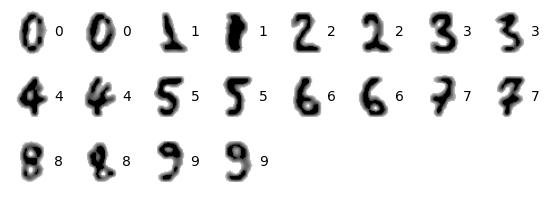

In [5]:
labeled_data = train[train["label"] != -1].sort_values(by="label")

plot_digits_grid(data=labeled_data, upscale=True)

---

### Modeling

You are required to use a Semi-Supervised Learning approach to improve performance.<br>
You are encouraged to use a classifier on the labled data points to set a baseline benchmark for yourself to improve.

In [ ]:
# Separate labeled samples from the training set
labeled_mask = y_train != -1
X_labeled = X_train[labeled_mask]
y_labeled = y_train[labeled_mask]

# Baseline: k-Nearest Neighbors trained on the 20 labeled samples only
# n_neighbors=1 avoids cross-class contamination with only 2 samples per class
baseline = KNeighborsClassifier(n_neighbors=1)
baseline.fit(X_labeled, y_labeled)

---

### Evaluation

Evalute your baseline model compared to semi-supervised learning methods

In [ ]:
y_pred_baseline = baseline.predict(X_validation)

baseline_acc = accuracy_score(y_validation, y_pred_baseline)
print(f"Baseline KNN accuracy: {baseline_acc:.3f}")
print()
print(classification_report(y_validation, y_pred_baseline))

---

### Semi-Supervised Learning: Pseudo-Labeling

Iteratively assigns high-confidence predictions from the current model as pseudo-labels,
then retrains on the expanded labeled set until no confident predictions remain.

In [ ]:
X_unlabeled = X_train[~labeled_mask].values
X_lab = X_labeled.values
y_lab = y_labeled.values


def pseudo_label(X_lab, y_lab, X_unlab, threshold=0.6, max_iters=10):
    X_L, y_L = X_lab.copy(), y_lab.copy()
    X_U = X_unlab.copy()

    for iteration in range(max_iters):
        k = min(5, max(1, len(X_L) // 10))
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_L, y_L)

        probs = model.predict_proba(X_U)
        confidence = probs.max(axis=1)
        pseudo_labels = model.classes_[probs.argmax(axis=1)]

        confident = confidence >= threshold
        if confident.sum() == 0:
            print(f"  Stopped at iteration {iteration + 1}: no confident predictions")
            break

        X_L = np.vstack([X_L, X_U[confident]])
        y_L = np.concatenate([y_L, pseudo_labels[confident]])
        X_U = X_U[~confident]
        print(f"  Iter {iteration + 1}: +{confident.sum()} pseudo-labels | labeled={len(X_L)} unlabeled={len(X_U)}")

        if len(X_U) == 0:
            break

    final_k = min(5, max(1, len(X_L) // 10))
    final = KNeighborsClassifier(n_neighbors=final_k)
    final.fit(X_L, y_L)
    return final


print("Pseudo-labeling:")
ssl_pseudo = pseudo_label(X_lab, y_lab, X_unlabeled, threshold=0.6)
y_pred_pseudo = ssl_pseudo.predict(X_validation)
pseudo_acc = accuracy_score(y_validation, y_pred_pseudo)
print(f"\nPseudo-labeling accuracy: {pseudo_acc:.3f}")
print()
print(classification_report(y_validation, y_pred_pseudo))

---

### Semi-Supervised Learning: Consistency Regularization

Assigns pseudo-labels only to unlabeled samples whose predictions remain stable
under multiple Gaussian noise perturbations, filtering out uncertain examples.

In [ ]:
def consistency_ssl(X_lab, y_lab, X_unlab, n_augs=15, noise_std=1.0):
    model = KNeighborsClassifier(n_neighbors=1)
    model.fit(X_lab, y_lab)

    rng = np.random.default_rng(42)

    # Predict unlabeled samples under multiple random perturbations
    aug_preds = np.stack([
        model.predict(X_unlab + rng.normal(0, noise_std, X_unlab.shape))
        for _ in range(n_augs)
    ])  # shape: (n_augs, n_unlabeled)

    # A sample is "consistent" if all augmented views agree on the same label
    base_preds = aug_preds[0]
    consistent = (aug_preds == base_preds).all(axis=0)
    print(f"Consistent unlabeled samples: {consistent.sum()} / {len(X_unlab)}")

    X_L = np.vstack([X_lab, X_unlab[consistent]])
    y_L = np.concatenate([y_lab, base_preds[consistent]])

    final_k = min(5, max(1, len(X_L) // 10))
    final = KNeighborsClassifier(n_neighbors=final_k)
    final.fit(X_L, y_L)
    return final


print("Consistency regularization:")
ssl_consistency = consistency_ssl(X_lab, y_lab, X_unlabeled, n_augs=15, noise_std=1.0)
y_pred_consistency = ssl_consistency.predict(X_validation)
consistency_acc = accuracy_score(y_validation, y_pred_consistency)
print(f"Consistency regularization accuracy: {consistency_acc:.3f}")
print()
print(classification_report(y_validation, y_pred_consistency))

---

### Comparison

In [ ]:
methods = ["Baseline KNN", "Pseudo-Labeling", "Consistency Reg."]
accuracies = [baseline_acc, pseudo_acc, consistency_acc]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(methods, accuracies, color=["steelblue", "mediumseagreen", "coral"])
ax.set_ylim(0, 1)
ax.set_ylabel("Validation Accuracy")
ax.set_title("SSL Method Comparison")
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.3f}", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

---

### Prediction

Make predictions on the test set

In [ ]:
results = [
    ("Baseline KNN",        baseline,        baseline_acc),
    ("Pseudo-Labeling",     ssl_pseudo,      pseudo_acc),
    ("Consistency Reg.",    ssl_consistency, consistency_acc),
]
best_name, best_model, best_acc = max(results, key=lambda x: x[2])
print(f"Best model: {best_name} (validation accuracy={best_acc:.3f})")

y_pred_submission = best_model.predict(X_test).astype(int)

---

### Submission

Use the provided save_submission function to save predictions

In [9]:
# save_submission(data=y_pred_submission)

---